In [1]:
import numpy as np
import hyperspy.api as hs
import os

In [2]:
import matplotlib.pyplot as plt

In [3]:
import logging
logging.getLogger("hyperspy").setLevel(logging.ERROR)

In [4]:
import colorcet as cc

In [48]:
from skimage.filters import gaussian

In [5]:
%matplotlib widget

In [6]:
work_dir = '/Users/nihy/Desktop/Working Data/CrSBr/CrSBr Strained exciton 20260922/export/120 K/Pitch/'
export_dir = os.path.join(work_dir, "Results")
if export_dir is not None and not os.path.exists(export_dir):
    os.makedirs(export_dir)

In [7]:
si_dir = os.path.join(work_dir, "Aligned (com) Sequence Synchronized EELS 3 +1 More (Apply Shifts).npy")

# Load Data

In [8]:
si = hs.signals.Signal1D(hs.load(si_dir, lazy = False))
si

<Signal1D, title: , dimensions: (256, 90, 20|1015)>

In [9]:
# images: array shaped (n_images, height, width)
valid = np.isfinite(si.data.sum(-1)) & (si.data.sum(-1) != 0)
common = valid.all(axis=0)

ys, xs = np.where(common)
if len(xs) == 0:
    raise ValueError("There is no common valid area")

y0, y1 = ys.min(), ys.max() + 1
x0, x1 = xs.min(), xs.max() + 1

#cropped = images[:, y0:y1, x0:x1]

In [10]:
si = si.inav[ x0:x1, y0:y1, :,]

In [11]:
si.set_signal_type("EELS")

/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazyComplexSignal1D` from `hyperspy._signals.complex_signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(


In [12]:
si.axes_manager[0].name = "x"
si.axes_manager[1].name = "y"
#si.axes_manager[2].name = "Frame"

In [13]:
si.axes_manager[-1].name = "Energy loss (eV)"
si.axes_manager[-1].units = "eV"
si.axes_manager[-1].scale = 0.00826990831799999
si.axes_manager[-1].offset = -0.826990831799999

In [14]:
si.plot()

The widget matplotlib backend is not compatible with the traitsui GUI elements. For more information, read https://hyperspy.readthedocs.io/en/stable/user_guide/basic_usage.html#possible-warnings-when-importing-hyperspy.


# Align ZLP

In [16]:
si.align_zero_loss_peak()

Initial ZLP position statistics
-------------------------------
Summary statistics
------------------
mean:	0.0193
std:	0.00389

min:	0.00827
Q1:	0.0165
median:	0.0165
Q3:	0.0248
max:	0.0331


  0%|          | 0/481 [00:00<?, ?it/s]

  0%|          | 0/91 [00:00<?, ?it/s]

  0%|          | 0/136 [00:00<?, ?it/s]

In [15]:
si_aligned = si.mean(axis = 2)
#si_aligned = si.deepcopy()

In [16]:
si_aligned.plot()

In [17]:
si_aligned.save(os.path.join(export_dir, "si_aligned.hspy"))

# pca_denoising

In [8]:
si_aligned_1 = hs.load('/Users/nihy/Desktop/Working Data/CrSBr/CrSBr Strained exciton 20260922/export/120 K/Pitch/Results/si_aligned.hspy')
si_aligned_2 = hs.load('/Users/nihy/Desktop/Working Data/CrSBr/CrSBr Strained exciton 20260922/export/120 K/Pitch Right/Results/si_aligned.hspy')

/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazyComplexSignal1D` from `hyperspy._signals.complex_signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(


In [9]:
si_aligned_1 = si_aligned_1.isig[-.5: 6.]
si_aligned_2 = si_aligned_2.isig[-.5: 6.]
si_aligned_1, si_aligned_2

(<EELSSpectrum, title: , dimensions: (251, 69|786)>,
 <EELSSpectrum, title: , dimensions: (251, 69|786)>)

In [10]:
si_aligned_1, si_aligned_2

(<EELSSpectrum, title: , dimensions: (251, 69|786)>,
 <EELSSpectrum, title: , dimensions: (251, 69|786)>)

In [11]:
si_aligned_combined = hs.stack([si_aligned_1, si_aligned_2])
si_aligned_combined

  0%|          | 0/14 [00:00<?, ?it/s]

<EELSSpectrum, title: Stack of , dimensions: (251, 69, 2|786)>

In [12]:
si_aligned_combined.align_zero_loss_peak()

Initial ZLP position statistics
-------------------------------
Summary statistics
------------------
mean:	0.00935
std:	0.00969

min:	5.55e-17
Q1:	5.55e-17
median:	0.0124
Q3:	0.0165
max:	0.0248


  0%|          | 0/1081 [00:00<?, ?it/s]

  0%|          | 0/721 [00:00<?, ?it/s]

  0%|          | 0/1081 [00:00<?, ?it/s]

In [13]:
si_aligned_combined.decomposition(algorithm="sklearn_pca")

Decomposition info:
  normalize_poissonian_noise=False
  algorithm=sklearn_pca
  output_dimension=None
  centre=None
scikit-learn estimator:
PCA()


<Axes: title={'center': 'Stack of \nPCA Scree Plot'}, xlabel='Principal component index', ylabel='Proportion of variance'>

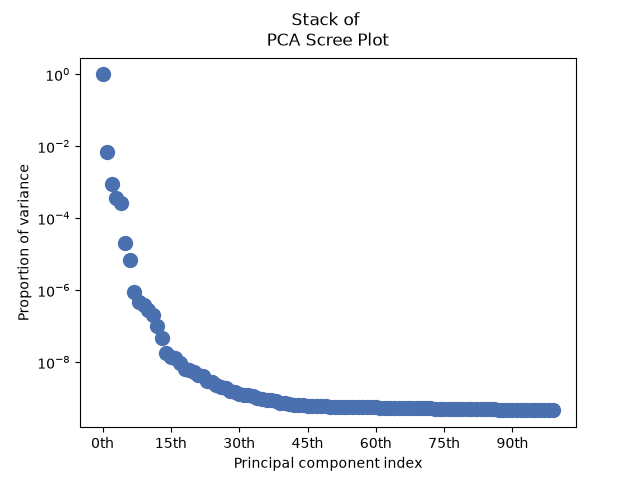

In [14]:
si_aligned_combined.plot_explained_variance_ratio(n=100)

# Background Subtraction

In [15]:
si_aligned_30 = si_aligned_combined.get_decomposition_model(components=30)
si_aligned_30 

<EELSSpectrum, title: Stack of  model from decomposition with 30 components, dimensions: (251, 69, 2|779)>

In [16]:
si_aligned_30.plot()

The widget matplotlib backend is not compatible with the traitsui GUI elements. For more information, read https://hyperspy.readthedocs.io/en/stable/user_guide/basic_usage.html#possible-warnings-when-importing-hyperspy.


In [17]:
si_aligned_30.mean((0,1)).plot()

In [18]:
si_aligned_30.plot()

In [19]:
mod = si_aligned_30.create_model()
#gaussian = hs.model.components1D.Gaussian() 
#mod.append(gaussian)

In [20]:
mod.components

   # |      Attribute Name |      Component Name |      Component Type
---- | ------------------- | ------------------- | -------------------
   0 |            PowerLaw |            PowerLaw |            PowerLaw

In [21]:
mod.set_signal_range(1.1, 1.3)

In [22]:
mod.multifit()

100%|██████████| 34638/34638 [00:33<00:00, 1038.12it/s]


In [23]:
mod.reset_signal_range()

In [24]:
mod.plot()

In [25]:
si_aligned_no_bkgd = si_aligned_30 - mod.as_signal()
si_aligned_no_bkgd.isig[:1.1] = 0

In [26]:
si_aligned_no_bkgd.plot()

# Fit "Band Edge (?)"

In [27]:
from scipy.optimize import curve_fit

In [28]:
def band_edge(x, x0, a):
    return a * np.clip(x - x0, 0, None)

In [29]:
e = si_aligned_30.axes_manager[-1].axis


In [30]:
i1 = si_aligned_no_bkgd.data[0,...]
i2 = si_aligned_no_bkgd.data[1,...]

In [31]:
e_fit = e[(e > 1.6) & (e < 2)]
i1_fit = i1[...,(e > 1.6) & (e < 2)]
i2_fit = i2[...,(e > 1.6) & (e < 2)]

In [32]:
indr, indc = np.random.randint(0, i1_fit.shape[0]), np.random.randint(0, i1_fit.shape[1])
y_data = i1_fit[indr, indc, :]
print(indr, indc)
popt, _ = curve_fit(band_edge, e_fit, y_data, p0=[1.6, 1], bounds = ([1.4, 0], [np.inf, np.inf]))
print(popt)

21 62
[1.54346015 0.41531103]


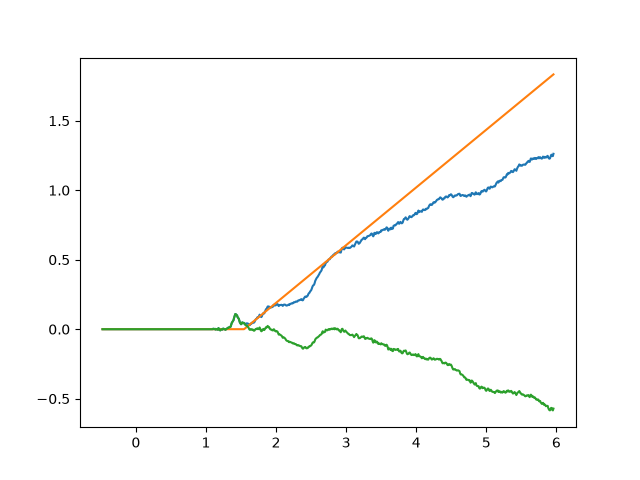

In [33]:
plt.figure()
plt.plot(e, i1[indr, indc])
plt.plot(e, band_edge(e, *popt))
plt.plot(e, i1[indr, indc] - band_edge(e, *popt))
plt.show()

In [34]:
i1_no_interband = np.zeros_like(i1)
for indr in range(i1.shape[0]):
    for indc in range(i1.shape[1]):
        y_data = i1_fit[indr, indc, :]
        try:
            popt, _ = curve_fit(band_edge, e_fit, y_data, p0=[1.6, 1], bounds = ([1.4, 0], [np.inf, np.inf]))
            i1_no_interband[indr, indc, :] = i1[indr, indc, :] - band_edge(e, *popt)
        except:
            i1_no_interband[indr, indc, :] = i1[indr, indc, :]

In [35]:
i2_no_interband = np.zeros_like(i2)
for indr in range(i2.shape[0]):
    for indc in range(i2.shape[1]):
        y_data = i2_fit[indr, indc, :]
        try:
            popt, _ = curve_fit(band_edge, e_fit, y_data, p0=[1.6, 1], bounds = ([1.4, 0], [np.inf, np.inf]))
            i2_no_interband[indr, indc, :] = i2[indr, indc, :] - band_edge(e, *popt)
        except:
            i2_no_interband[indr, indc, :] = i2[indr, indc, :]

In [36]:
i1_no_interband = hs.signals.Signal1D(i1_no_interband)
i2_no_interband = hs.signals.Signal1D(i2_no_interband)

In [37]:
i2_no_interband.plot()

# Fit 1s Excition using Gaussian

In [38]:
def Gaussian(x, amp, cen, wid):
    return amp * np.exp(-(x-cen)**2 / (2*wid**2))

In [39]:
e_fit = e[(e > 1.3) & (e < 1.5)]
i1_fit = i1_no_interband.data[...,(e > 1.3) & (e < 1.5)]
i2_fit = i2_no_interband.data[...,(e > 1.3) & (e < 1.5)]

In [40]:
indr, indc = np.random.randint(0, i1_fit.shape[0]), np.random.randint(0, i1_fit.shape[1])
y_data = i1_fit[indr, indc, :]
print(indr, indc)
popt_i1, _ = curve_fit(Gaussian, e_fit, y_data, p0=[2, 1.4, 1], bounds = ([0, 1.2, 0], [np.inf, 1.6, np.inf]))
print(popt_i1)

19 227
[0.14102321 1.43618426 0.05041845]


In [41]:
indr, indc = np.random.randint(0, i2_fit.shape[0]), np.random.randint(0, i2_fit.shape[1])
y_data = i2_fit[indr, indc, :]
print(indr, indc)
popt_i2, _ = curve_fit(Gaussian, e_fit, y_data, p0=[2, 1.4, 1], bounds = ([0, 1.2, 0], [np.inf, 1.6, np.inf]))
print(popt_i2)

33 43
[0.1198836  1.4303149  0.04098523]


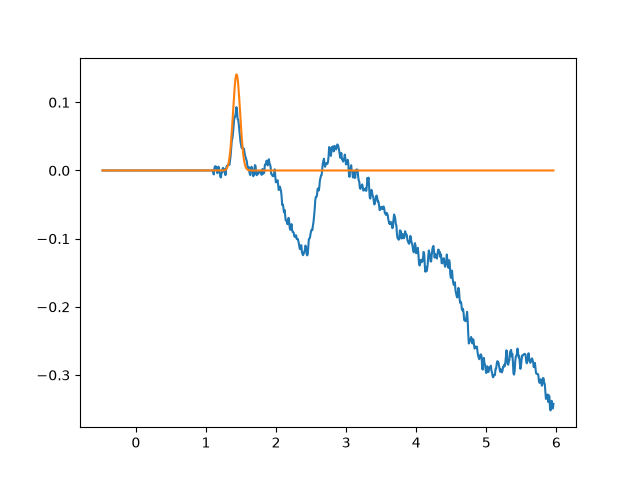

In [42]:
plt.figure()
plt.plot(e, i1_no_interband.data[indr, indc])
plt.plot(e, Gaussian(e, *popt_i1))
#plt.plot(e, i[indr, indc] - band_edge(e, *popt))
plt.show()

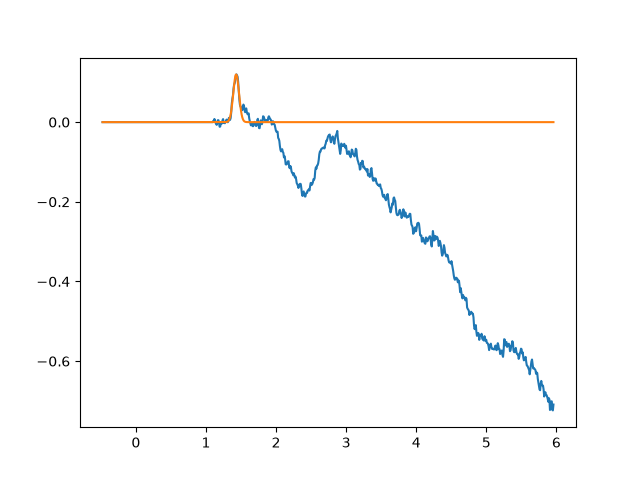

In [43]:
plt.figure()
plt.plot(e, i2_no_interband.data[indr, indc])
plt.plot(e, Gaussian(e, *popt_i2))
#plt.plot(e, i[indr, indc] - band_edge(e, *popt))
plt.show()

In [44]:
gaussian_params_i1 = np.zeros(i1_fit.shape[:2] + (3,))
for indr in range(i1.shape[0]):
    for indc in range(i1.shape[1]):
        y_data = i1_fit[indr, indc, :]
        try:
            popt, _ = curve_fit(Gaussian, e_fit, y_data, p0=[2, 1.4, 1], bounds = ([0, 1.2, 0], [np.inf, 1.6, np.inf]))
            gaussian_params_i1[indr, indc, :] = popt  # store amplitude and center of the Gaussian
        except:
            gaussian_params_i1[indr, indc, :] = np.nan  # assign NaN if fitting fails

In [45]:
gaussian_params_i2 = np.zeros(i2_fit.shape[:2] + (3,))
for indr in range(i2.shape[0]):
    for indc in range(i2.shape[1]):
        y_data = i2_fit[indr, indc, :]
        try:
            popt, _ = curve_fit(Gaussian, e_fit, y_data, p0=[2, 1.4, 1], bounds = ([0, 1.2, 0], [np.inf, 1.6, np.inf]))
            gaussian_params_i2[indr, indc, :] = popt  # store amplitude and center of the Gaussian
        except:
            gaussian_params_i2[indr, indc, :] = np.nan  # assign NaN if fitting fails

Text(0.5, 1.0, 'position')

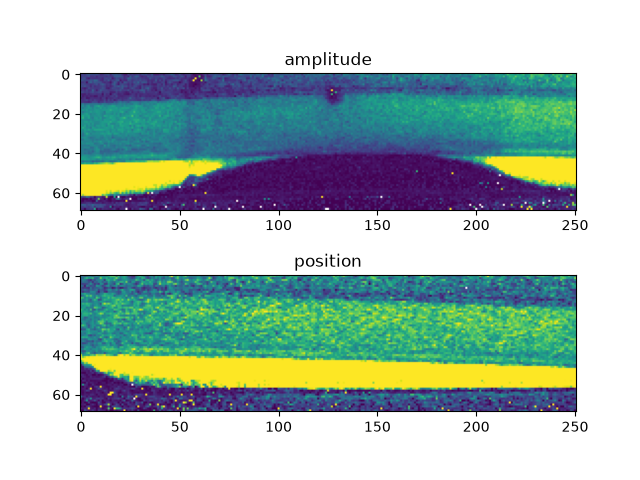

In [46]:
_, axs = plt.subplots(2, 1, dpi = 100)
axs[0].imshow(gaussian_params_i1[..., 0], vmax = 0.2)
axs[0].set_title("amplitude")

axs[1].imshow(gaussian_params_i2[..., 0], vmax = 0.2)
axs[1].set_title("position")

Text(0.5, 1.0, 'position')

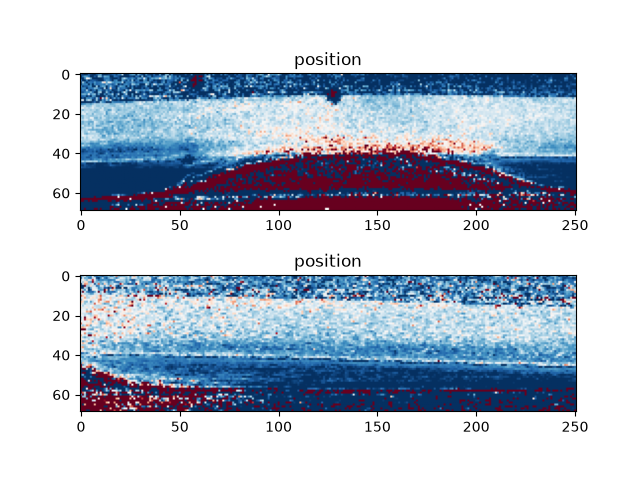

In [47]:
_, axs = plt.subplots(2, 1, dpi = 100)
axs[0].imshow(gaussian_params_i1[..., 1], vmax = 1.46, vmin = 1.42 , cmap = 'RdBu_r')
axs[0].set_title("position")

axs[1].imshow(gaussian_params_i2[..., 1], vmax = 1.46, vmin = 1.42, cmap = 'RdBu_r')
axs[1].set_title("position")

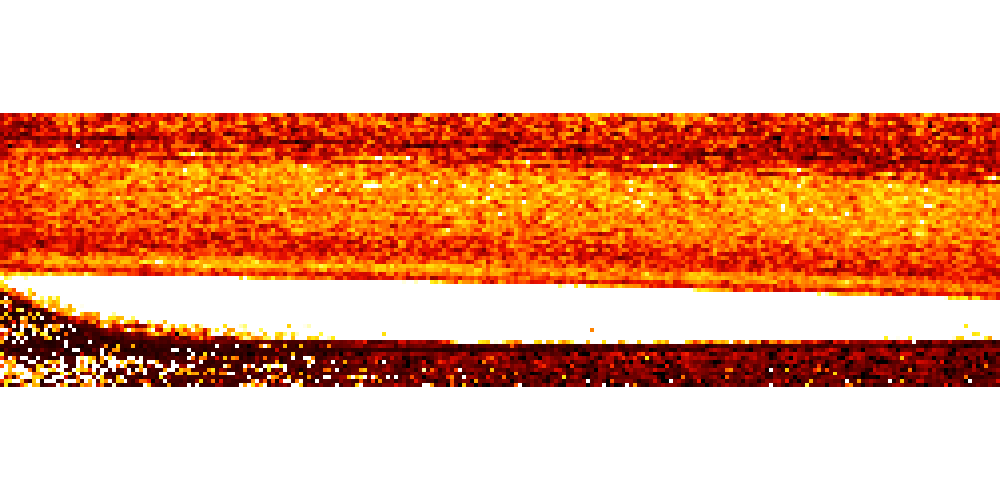

In [42]:
plt.figure(figsize = (10, 5))
plt.subplots_adjust(0, 0, 1, 1)
ax = plt.gca()
plt.imshow(gaussian_params[..., 0], vmax = 0.2, cmap = cc.cm.fire)
plt.axis("off")
plt.savefig(os.path.join(export_dir, "amplitude.png"), dpi = 300, bbox_inches='tight', pad_inches=0)


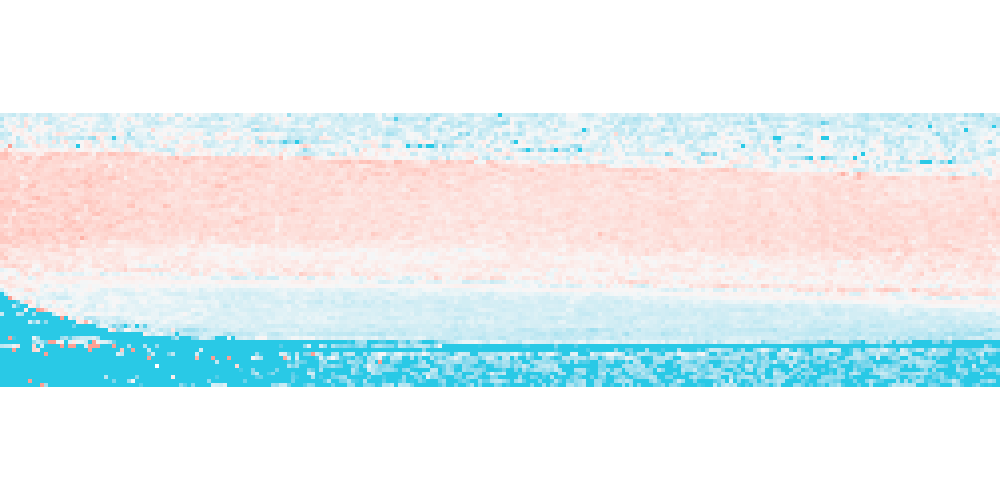

In [43]:
plt.figure(figsize = (10, 5))
plt.subplots_adjust(0, 0, 1, 1)
ax = plt.gca()
plt.imshow(gaussian_params[..., 1], vmin = 1.4, vmax = 1.46, cmap = cc.cm.cwr)
plt.axis("off")
plt.savefig(os.path.join(export_dir, "position.png"), dpi = 300, bbox_inches='tight', pad_inches=0)
